In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
diabetes_data = load_diabetes()

features_df = pd.DataFrame(
    diabetes_data.data,
    columns=diabetes_data.feature_names
)

target_series = pd.Series(
    diabetes_data.target,
    name="disease_progression"
)

diabetes_df = features_df.copy()
diabetes_df["disease_progression"] = target_series

diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
# Dataset Preview

The Diabetes dataset contains numerical health measurements that are used to predict disease progression. The target variable is continuous, making this dataset suitable for regression analysis.

In [3]:
dataset_overview = pd.DataFrame({
    "Dataset Detail": [
        "Number of records",
        "Number of input features",
        "Target column",
        "Feature names"
    ],
    "Value": [
        features_df.shape[0],
        features_df.shape[1],
        "disease_progression",
        ", ".join(features_df.columns)
    ]
})

dataset_overview

,Dataset Detail,Value
0,Number of records,442
1,Number of input features,10
2,Target column,disease_progression
3,Feature names,"age, sex, bmi, bp, s1, s2, s3, s4, s5, s6"


In [4]:
diabetes_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.268604e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


In [ ]:
# Dataset Summary

The summary statistics show the spread of each feature and the target variable. Since the Diabetes dataset from scikit-learn is already numeric and scaled, it is ready for regression modeling.

In [5]:
missing_values = diabetes_df.isnull().sum().reset_index()
missing_values.columns = ["Column", "Missing Values"]

missing_values

,Column,Missing Values
0,age,0
1,sex,0
2,bmi,0
3,bp,0
4,s1,0
5,s2,0
6,s3,0
7,s4,0
8,s5,0
9,s6,0


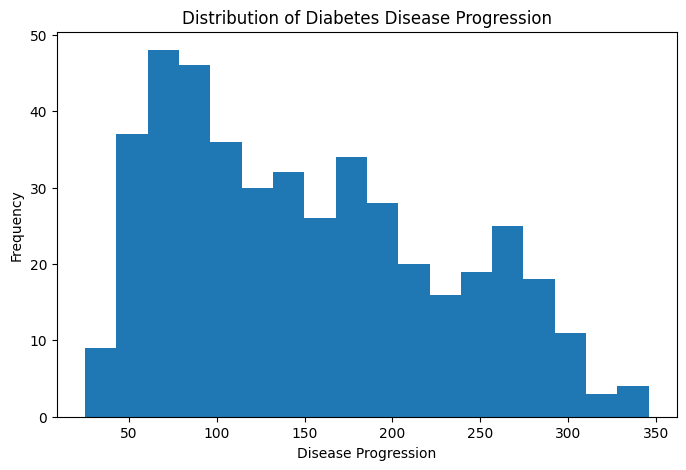

In [6]:
plt.figure(figsize=(8, 5))

plt.hist(
    diabetes_df["disease_progression"],
    bins=18
)

plt.title("Distribution of Diabetes Disease Progression")
plt.xlabel("Disease Progression")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Target Distribution

The histogram shows that disease progression values vary across patients. This variation provides a meaningful continuous outcome for regression modeling.

In [7]:
def evaluate_regression_model(model_name, actual_values, predicted_values):
    mae = mean_absolute_error(actual_values, predicted_values)
    mse = mean_squared_error(actual_values, predicted_values)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual_values, predicted_values)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

print("Evaluation function created")

Evaluation function created


In [8]:
X_simple_v = features_df[["s5"]]
y_v = target_series

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple_v,
    y_v,
    test_size=0.2,
    random_state=24
)

simple_regressor = LinearRegression()
simple_regressor.fit(X_train_s, y_train_s)

simple_pred_v = simple_regressor.predict(X_test_s)

simple_result_v = pd.DataFrame([
    evaluate_regression_model(
        "Simple Linear Regression (s5)",
        y_test_s,
        simple_pred_v
    )
])

simple_result_v

,Model,MAE,MSE,RMSE,R2
0,Simple Linear Regression (s5),50.860566,3556.830231,59.639167,0.355881


In [ ]:
# Simple Linear Regression

The `s5` feature was selected for Simple Linear Regression because it has a meaningful relationship with the target variable. This model provides a baseline for comparing more advanced regression models.

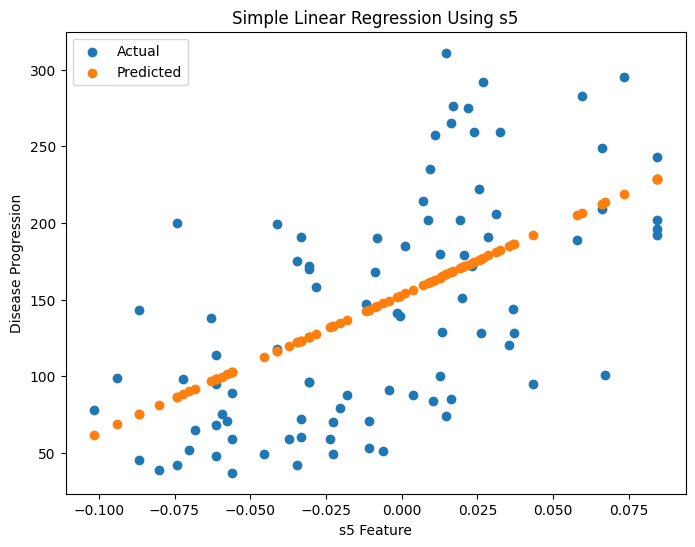

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_s["s5"],
    y_test_s,
    label="Actual"
)

plt.scatter(
    X_test_s["s5"],
    simple_pred_v,
    label="Predicted"
)

plt.title("Simple Linear Regression Using s5")
plt.xlabel("s5 Feature")
plt.ylabel("Disease Progression")
plt.legend()

plt.show()

In [10]:
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    features_df,
    target_series,
    test_size=0.2,
    random_state=24
)

multi_regressor = LinearRegression()
multi_regressor.fit(X_train_full, y_train_full)

multi_pred_v = multi_regressor.predict(X_test_full)

multiple_result_v = pd.DataFrame([
    evaluate_regression_model(
        "Multiple Linear Regression",
        y_test_full,
        multi_pred_v
    )
])

multiple_result_v

,Model,MAE,MSE,RMSE,R2
0,Multiple Linear Regression,47.001529,3186.044009,56.445053,0.423028


In [ ]:
# Multiple Regression

Multiple Regression uses all available health measurements as predictors. This allows the model to capture more information than Simple Linear Regression.

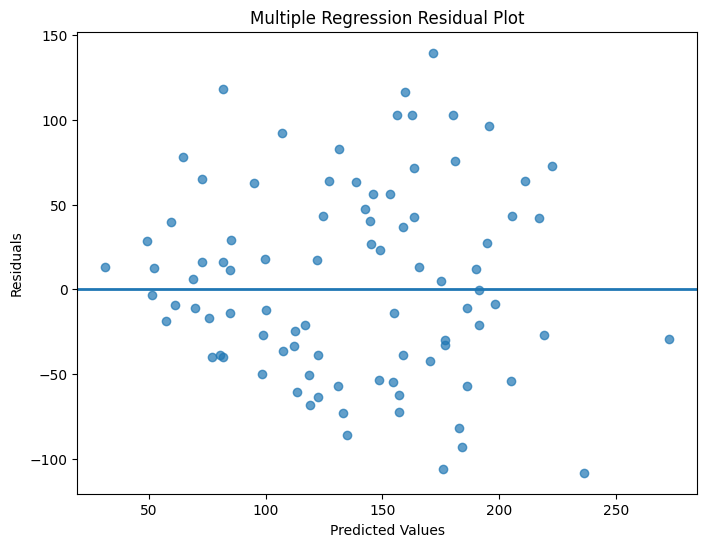

In [11]:
multi_residuals = y_test_full - multi_pred_v

plt.figure(figsize=(8, 6))

plt.scatter(
    multi_pred_v,
    multi_residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linewidth=2
)

plt.title("Multiple Regression Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

In [ ]:
# Residual Analysis

The residual plot shows the difference between actual and predicted values. A good model should have residuals distributed around zero without a strong pattern.

In [12]:
poly_degree_2 = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly2_v = poly_degree_2.fit_transform(features_df)

X_train_poly2, X_test_poly2, y_train_poly2, y_test_poly2 = train_test_split(
    X_poly2_v,
    target_series,
    test_size=0.2,
    random_state=24
)

poly2_regressor = LinearRegression()
poly2_regressor.fit(X_train_poly2, y_train_poly2)

poly2_pred_v = poly2_regressor.predict(X_test_poly2)

poly2_result_v = pd.DataFrame([
    evaluate_regression_model(
        "Polynomial Regression Degree 2",
        y_test_poly2,
        poly2_pred_v
    )
])

poly2_result_v

,Model,MAE,MSE,RMSE,R2
0,Polynomial Regression Degree 2,43.961234,3003.409131,54.803368,0.456102


In [13]:
poly_degree_4 = PolynomialFeatures(
    degree=4,
    include_bias=False
)

X_poly4_v = poly_degree_4.fit_transform(features_df)

X_train_poly4, X_test_poly4, y_train_poly4, y_test_poly4 = train_test_split(
    X_poly4_v,
    target_series,
    test_size=0.2,
    random_state=24
)

poly4_regressor = LinearRegression()
poly4_regressor.fit(X_train_poly4, y_train_poly4)

poly4_pred_v = poly4_regressor.predict(X_test_poly4)

poly4_result_v = pd.DataFrame([
    evaluate_regression_model(
        "Polynomial Regression Degree 4",
        y_test_poly4,
        poly4_pred_v
    )
])

poly4_result_v

,Model,MAE,MSE,RMSE,R2
0,Polynomial Regression Degree 4,218.915766,94527.456789,307.453178,-16.118323


In [ ]:
# Polynomial Regression

Polynomial Regression adds nonlinear and interaction terms to the model. Degree 2 provides moderate complexity, while Degree 4 tests whether higher complexity improves or harms performance. If performance becomes worse, it may indicate overfitting.

In [14]:
ridge_alpha_values = [0.01, 0.1, 1.0, 10.0]

ridge_results_list = []

for alpha_value in ridge_alpha_values:
    ridge_model_v = Ridge(alpha=alpha_value)
    ridge_model_v.fit(X_train_full, y_train_full)

    ridge_pred_v = ridge_model_v.predict(X_test_full)

    result = evaluate_regression_model(
        f"Ridge Regression alpha={alpha_value}",
        y_test_full,
        ridge_pred_v
    )

    ridge_results_list.append(result)

ridge_results_v = pd.DataFrame(ridge_results_list)

ridge_results_v

,Model,MAE,MSE,RMSE,R2
0,Ridge Regression alpha=0.01,46.878674,3192.668527,56.503704,0.421828
1,Ridge Regression alpha=0.1,46.765088,3173.272330,56.331806,0.425341
2,Ridge Regression alpha=1.0,49.995974,3398.859014,58.299734,0.384488
3,Ridge Regression alpha=10.0,60.833678,4785.292978,69.175812,0.133414


In [ ]:
# Ridge Regression

Ridge Regression applies L2 regularization. Increasing alpha makes the model more restricted by shrinking coefficient values. This can reduce overfitting, but very large alpha values may cause underfitting.

In [15]:
lasso_alpha_values = [0.001, 0.01, 0.1, 1.0]

lasso_results_list = []

for alpha_value in lasso_alpha_values:
    lasso_model_v = Lasso(
        alpha=alpha_value,
        max_iter=10000
    )

    lasso_model_v.fit(X_train_full, y_train_full)

    lasso_pred_v = lasso_model_v.predict(X_test_full)

    result = evaluate_regression_model(
        f"Lasso Regression alpha={alpha_value}",
        y_test_full,
        lasso_pred_v
    )

    lasso_results_list.append(result)

lasso_results_v = pd.DataFrame(lasso_results_list)

lasso_results_v

,Model,MAE,MSE,RMSE,R2
0,Lasso Regression alpha=0.001,46.973532,3187.718709,56.459886,0.422724
1,Lasso Regression alpha=0.01,46.832645,3195.494698,56.528707,0.421316
2,Lasso Regression alpha=0.1,46.634350,3202.810077,56.593375,0.419991
3,Lasso Regression alpha=1.0,54.766136,3973.223064,63.033507,0.280475


In [ ]:
# Lasso Regression

Lasso Regression applies L1 regularization. It can shrink some coefficients close to zero, which helps simplify the model and reduce the influence of weaker predictors.

In [16]:
all_model_results = pd.concat(
    [
        simple_result_v,
        multiple_result_v,
        poly2_result_v,
        poly4_result_v,
        ridge_results_v,
        lasso_results_v
    ],
    ignore_index=True
)

model_ranking = all_model_results.sort_values(
    by=["R2", "RMSE"],
    ascending=[False, True]
)

model_ranking

,Model,MAE,MSE,RMSE,R2
2,Polynomial Regression Degree 2,43.961234,3003.409131,54.803368,0.456102
5,Ridge Regression alpha=0.1,46.765088,3173.272330,56.331806,0.425341
1,Multiple Linear Regression,47.001529,3186.044009,56.445053,0.423028
8,Lasso Regression alpha=0.001,46.973532,3187.718709,56.459886,0.422724
4,Ridge Regression alpha=0.01,46.878674,3192.668527,56.503704,0.421828
9,Lasso Regression alpha=0.01,46.832645,3195.494698,56.528707,0.421316
10,Lasso Regression alpha=0.1,46.634350,3202.810077,56.593375,0.419991
6,Ridge Regression alpha=1.0,49.995974,3398.859014,58.299734,0.384488
0,Simple Linear Regression (s5),50.860566,3556.830231,59.639167,0.355881
11,Lasso Regression alpha=1.0,54.766136,3973.223064,63.033507,0.280475


In [17]:
best_model_name = model_ranking.iloc[0]["Model"]

print("Best model based on highest R2 and lower RMSE:")
print(best_model_name)

Best model based on highest R2 and lower RMSE:
Polynomial Regression Degree 2


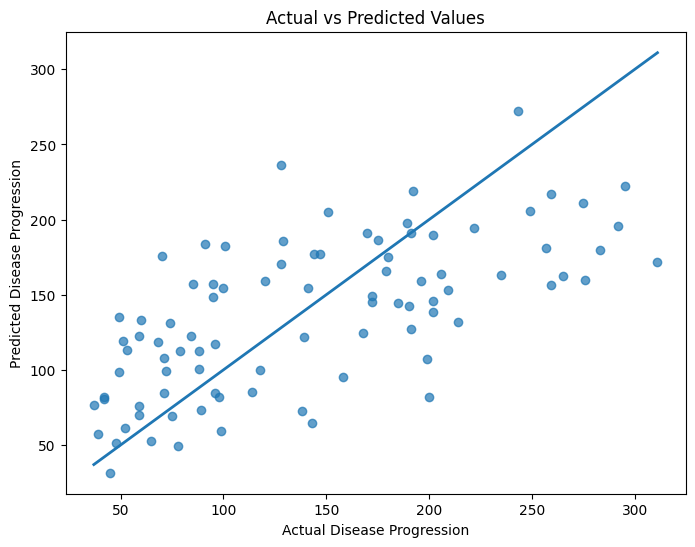

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_full,
    multi_pred_v,
    alpha=0.7
)

plt.plot(
    [y_test_full.min(), y_test_full.max()],
    [y_test_full.min(), y_test_full.max()],
    linewidth=2
)

plt.title("Actual vs Predicted Values")
plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")

plt.show()